<a href="https://www.kaggle.com/code/sonawanelalitsunil/men-s-health-lifestyle-insights-ml-92-38?scriptVersionId=232723211" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/health-and-lifestyle-dataset/health_activity_data.csv


## Title: Men's Health & Lifestyle Insights

### Description:
A comprehensive dataset capturing health, fitness, diet, and daily habits of men across different age groups. Includes metrics like exercise routines, sleep patterns, diet preferences, stress levels, and medical checkups to help analyze lifestyle trends and improve well-being.

In [2]:
df = pd.read_csv('/kaggle/input/health-and-lifestyle-dataset/health_activity_data.csv')

In [3]:
df.head()

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Blood_Pressure,Exercise_Hours_per_Week,Smoker,Alcohol_Consumption_per_Week,Diabetic,Heart_Disease
0,1,56,Male,164,81,30.72,5134,1796,8.6,102,137/72,8.1,No,7,No,No
1,2,69,Male,156,82,20.86,12803,1650,4.5,103,129/65,3.7,No,7,No,No
2,3,46,Female,158,65,30.93,16408,1756,4.3,74,127/68,3.2,Yes,0,No,No
3,4,32,Male,197,87,31.19,18420,2359,4.1,116,125/86,8.5,No,5,No,No
4,5,60,Male,157,63,29.37,17351,2556,5.1,111,100/64,8.5,Yes,8,No,No


In [4]:
df.tail()

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Blood_Pressure,Exercise_Hours_per_Week,Smoker,Alcohol_Consumption_per_Week,Diabetic,Heart_Disease
995,996,18,Male,179,116,31.67,10095,2667,4.6,79,108/63,6.3,No,5,No,No
996,997,35,Female,170,114,23.88,11361,2351,7.2,54,98/75,2.9,No,3,No,Yes
997,998,49,Female,169,85,23.44,9531,2416,4.5,80,125/65,7.6,No,4,No,No
998,999,64,Male,155,74,22.34,5270,2080,5.8,101,129/86,5.4,No,4,No,No
999,1000,66,Female,171,86,20.64,10906,1284,8.5,72,118/83,1.3,No,1,No,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   object 
 3   Height_cm                     1000 non-null   int64  
 4   Weight_kg                     1000 non-null   int64  
 5   BMI                           1000 non-null   float64
 6   Daily_Steps                   1000 non-null   int64  
 7   Calories_Intake               1000 non-null   int64  
 8   Hours_of_Sleep                1000 non-null   float64
 9   Heart_Rate                    1000 non-null   int64  
 10  Blood_Pressure                1000 non-null   object 
 11  Exercise_Hours_per_Week       1000 non-null   float64
 12  Smoker                        1000 non-null   object 
 13  Alco

In [6]:
df.describe()

,ID,Age,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Exercise_Hours_per_Week,Alcohol_Consumption_per_Week
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,49.857000,174.74500,84.35200,26.729510,10717.034000,2327.117000,6.90990,84.710000,5.045500,4.573000
std,288.819436,18.114267,14.54192,20.06596,4.786341,5444.707891,657.847942,1.77964,20.130155,2.847801,2.852509
min,1.000000,18.000000,150.00000,50.00000,18.500000,1016.000000,1201.000000,4.00000,50.000000,0.000000,0.000000
25%,250.750000,35.000000,162.00000,68.00000,22.600000,6028.250000,1745.750000,5.30000,67.000000,2.675000,2.000000
50%,500.500000,50.000000,175.00000,84.00000,26.800000,10898.000000,2328.500000,6.90000,84.000000,5.100000,5.000000
75%,750.250000,66.000000,187.00000,101.00000,30.850000,15253.250000,2880.000000,8.40000,103.000000,7.600000,7.000000
max,1000.000000,79.000000,199.00000,119.00000,34.980000,19931.000000,3498.000000,10.00000,119.000000,10.000000,9.000000


In [7]:
df.isnull().sum()

ID                              0
Age                             0
Gender                          0
Height_cm                       0
Weight_kg                       0
BMI                             0
Daily_Steps                     0
Calories_Intake                 0
Hours_of_Sleep                  0
Heart_Rate                      0
Blood_Pressure                  0
Exercise_Hours_per_Week         0
Smoker                          0
Alcohol_Consumption_per_Week    0
Diabetic                        0
Heart_Disease                   0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(1000, 16)

In [10]:
df.dtypes

ID                                int64
Age                               int64
Gender                           object
Height_cm                         int64
Weight_kg                         int64
BMI                             float64
Daily_Steps                       int64
Calories_Intake                   int64
Hours_of_Sleep                  float64
Heart_Rate                        int64
Blood_Pressure                   object
Exercise_Hours_per_Week         float64
Smoker                           object
Alcohol_Consumption_per_Week      int64
Diabetic                         object
Heart_Disease                    object
dtype: object

In [11]:
df.columns

Index(['ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Steps',
       'Calories_Intake', 'Hours_of_Sleep', 'Heart_Rate', 'Blood_Pressure',
       'Exercise_Hours_per_Week', 'Smoker', 'Alcohol_Consumption_per_Week',
       'Diabetic', 'Heart_Disease'],
      dtype='object')

## Data visualizations

In [12]:
# Filter for male
df = df[df['Gender'] == 'Male']

# Basic overview
print(df.describe())

               ID         Age   Height_cm   Weight_kg         BMI  \
count  523.000000  523.000000  523.000000  523.000000  523.000000   
mean   498.239006   50.483748  174.674952   84.260038   26.578834   
std    292.799675   18.132685   14.708974   20.231071    4.737504   
min      1.000000   18.000000  150.000000   50.000000   18.560000   
25%    241.500000   36.000000  161.000000   67.000000   22.335000   
50%    498.000000   50.000000  175.000000   84.000000   26.760000   
75%    748.000000   67.000000  187.500000  101.000000   30.395000   
max    999.000000   79.000000  199.000000  119.000000   34.950000   

        Daily_Steps  Calories_Intake  Hours_of_Sleep  Heart_Rate  \
count    523.000000       523.000000      523.000000  523.000000   
mean   10960.172084      2315.738050        6.922945   84.749522   
std     5387.792999       654.307535        1.731146   19.646697   
min     1016.000000      1201.000000        4.000000   50.000000   
25%     6406.500000      1761.000000  

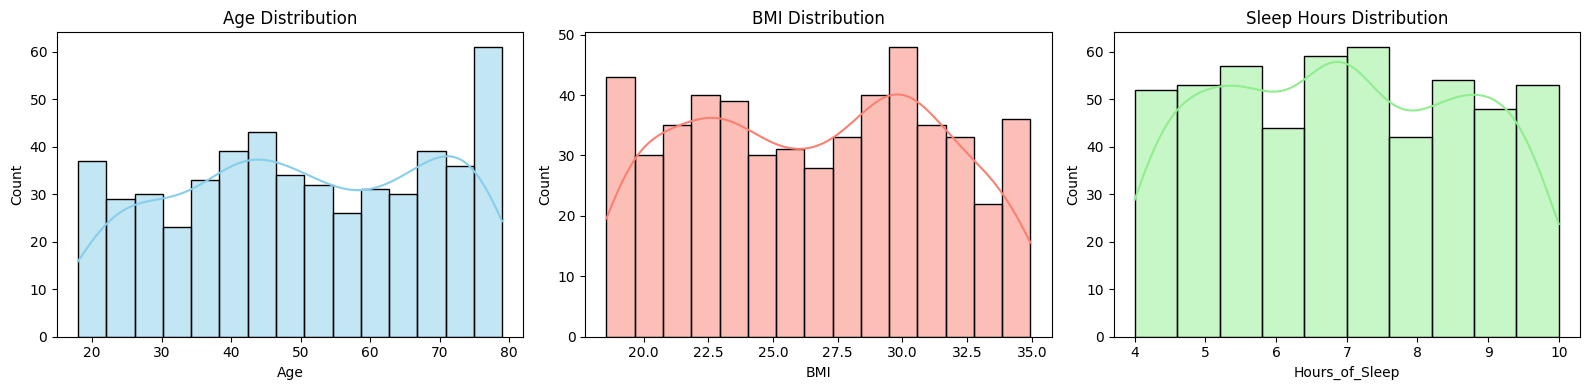

In [13]:
plt.figure(figsize=(16, 4))

# Age distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')
plt.title('Age Distribution')

# BMI distribution
plt.subplot(1, 3, 2)
sns.histplot(df['BMI'], bins=15, kde=True, color='salmon')
plt.title('BMI Distribution')

# Sleep hours
plt.subplot(1, 3, 3)
sns.histplot(df['Hours_of_Sleep'], bins=10, kde=True, color='lightgreen')
plt.title('Sleep Hours Distribution')

plt.tight_layout()
plt.show()


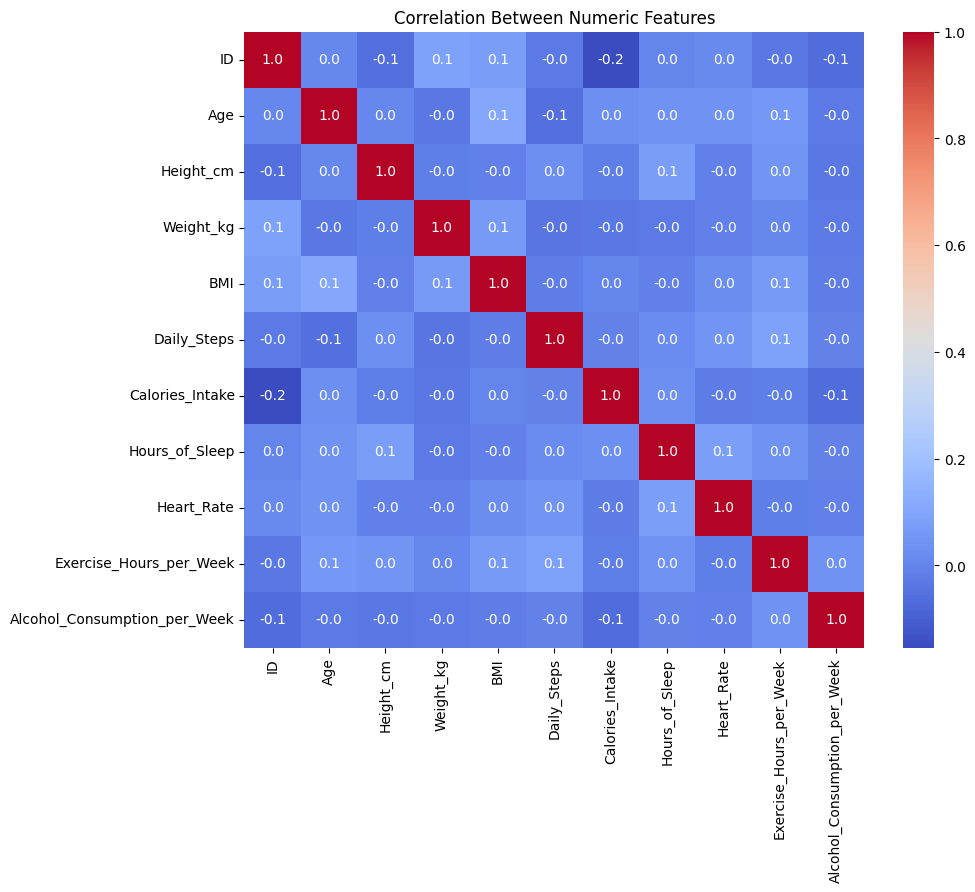

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f", cmap='coolwarm')
plt.title("Correlation Between Numeric Features")
plt.show()


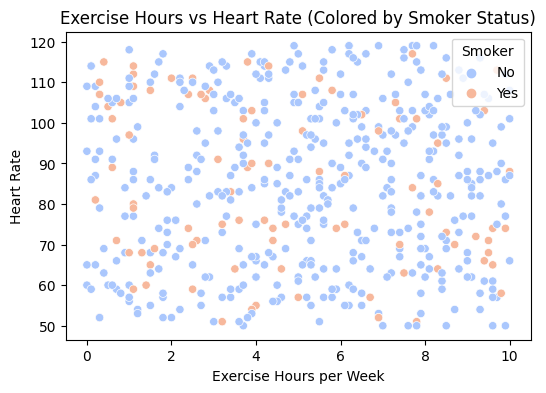

In [15]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Exercise_Hours_per_Week', y='Heart_Rate', hue='Smoker', palette='coolwarm')
plt.title('Exercise Hours vs Heart Rate (Colored by Smoker Status)')
plt.xlabel('Exercise Hours per Week')
plt.ylabel('Heart Rate')
plt.show()


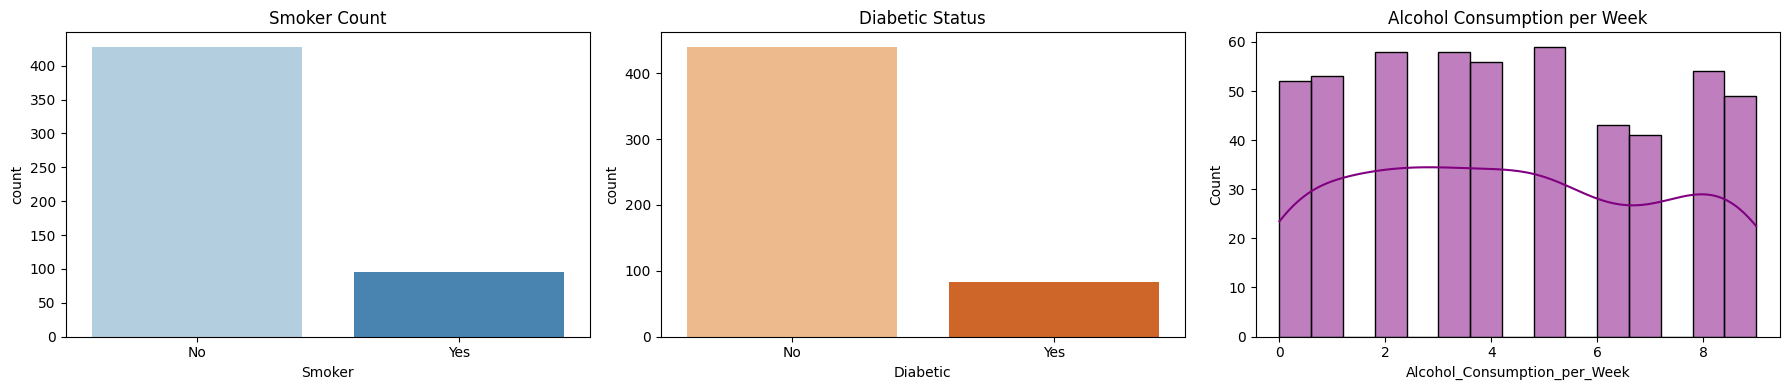

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(x='Smoker', data=df, ax=axs[0], palette='Blues')
axs[0].set_title('Smoker Count')

sns.countplot(x='Diabetic', data=df, ax=axs[1], palette='Oranges')
axs[1].set_title('Diabetic Status')

sns.histplot(df['Alcohol_Consumption_per_Week'], bins=15, kde=True, ax=axs[2], color='purple')
axs[2].set_title('Alcohol Consumption per Week')

plt.tight_layout()
plt.show()


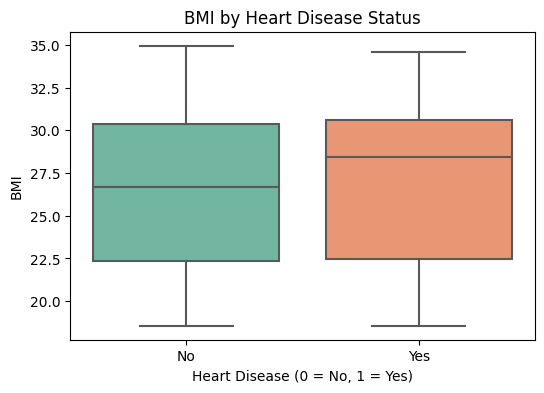

In [17]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Heart_Disease', y='BMI', palette='Set2')
plt.title('BMI by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('BMI')
plt.show()


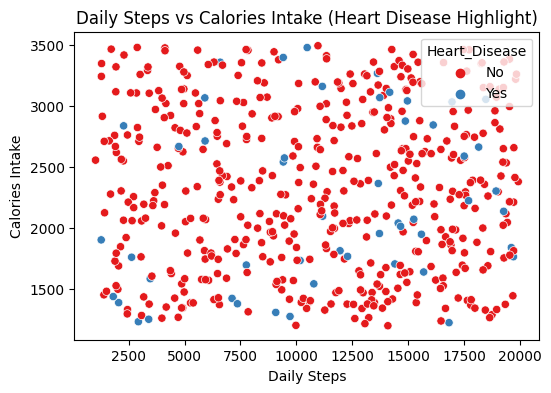

In [18]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Daily_Steps', y='Calories_Intake', hue='Heart_Disease', palette='Set1')
plt.title('Daily Steps vs Calories Intake (Heart Disease Highlight)')
plt.xlabel('Daily Steps')
plt.ylabel('Calories Intake')
plt.show()


## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

In [21]:
# Safely drop columns if they exist
cols_to_drop = ['ID', 'Gender', 'Blood_Pressure']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)


In [22]:
# Only split if 'Blood_Pressure' exists
if 'Blood_Pressure' in df.columns:
    df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure'].str.split('/', expand=True).astype(int)

# Safely drop columns that may already be gone
cols_to_drop = ['ID', 'Gender', 'Blood_Pressure']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

# Label encode binary columns
le = LabelEncoder()
for col in ['Smoker', 'Diabetic', 'Heart_Disease']:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Define features and target
X = df.drop('Heart_Disease', axis=1)
y = df['Heart_Disease']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)
    
    results.append((name, acc, cm))


In [24]:
print(f"{'Model':<25}{'Accuracy (%)':>15}")
print("-" * 40)
for name, acc, _ in results:
    print(f"{name:<25}{acc:>15.2f}")


Model                       Accuracy (%)
----------------------------------------
Logistic Regression                92.38
Decision Tree                      81.90
Random Forest                      92.38
Support Vector Machine             92.38
K-Nearest Neighbors                92.38
Naive Bayes                        92.38
Gradient Boosting                  87.62


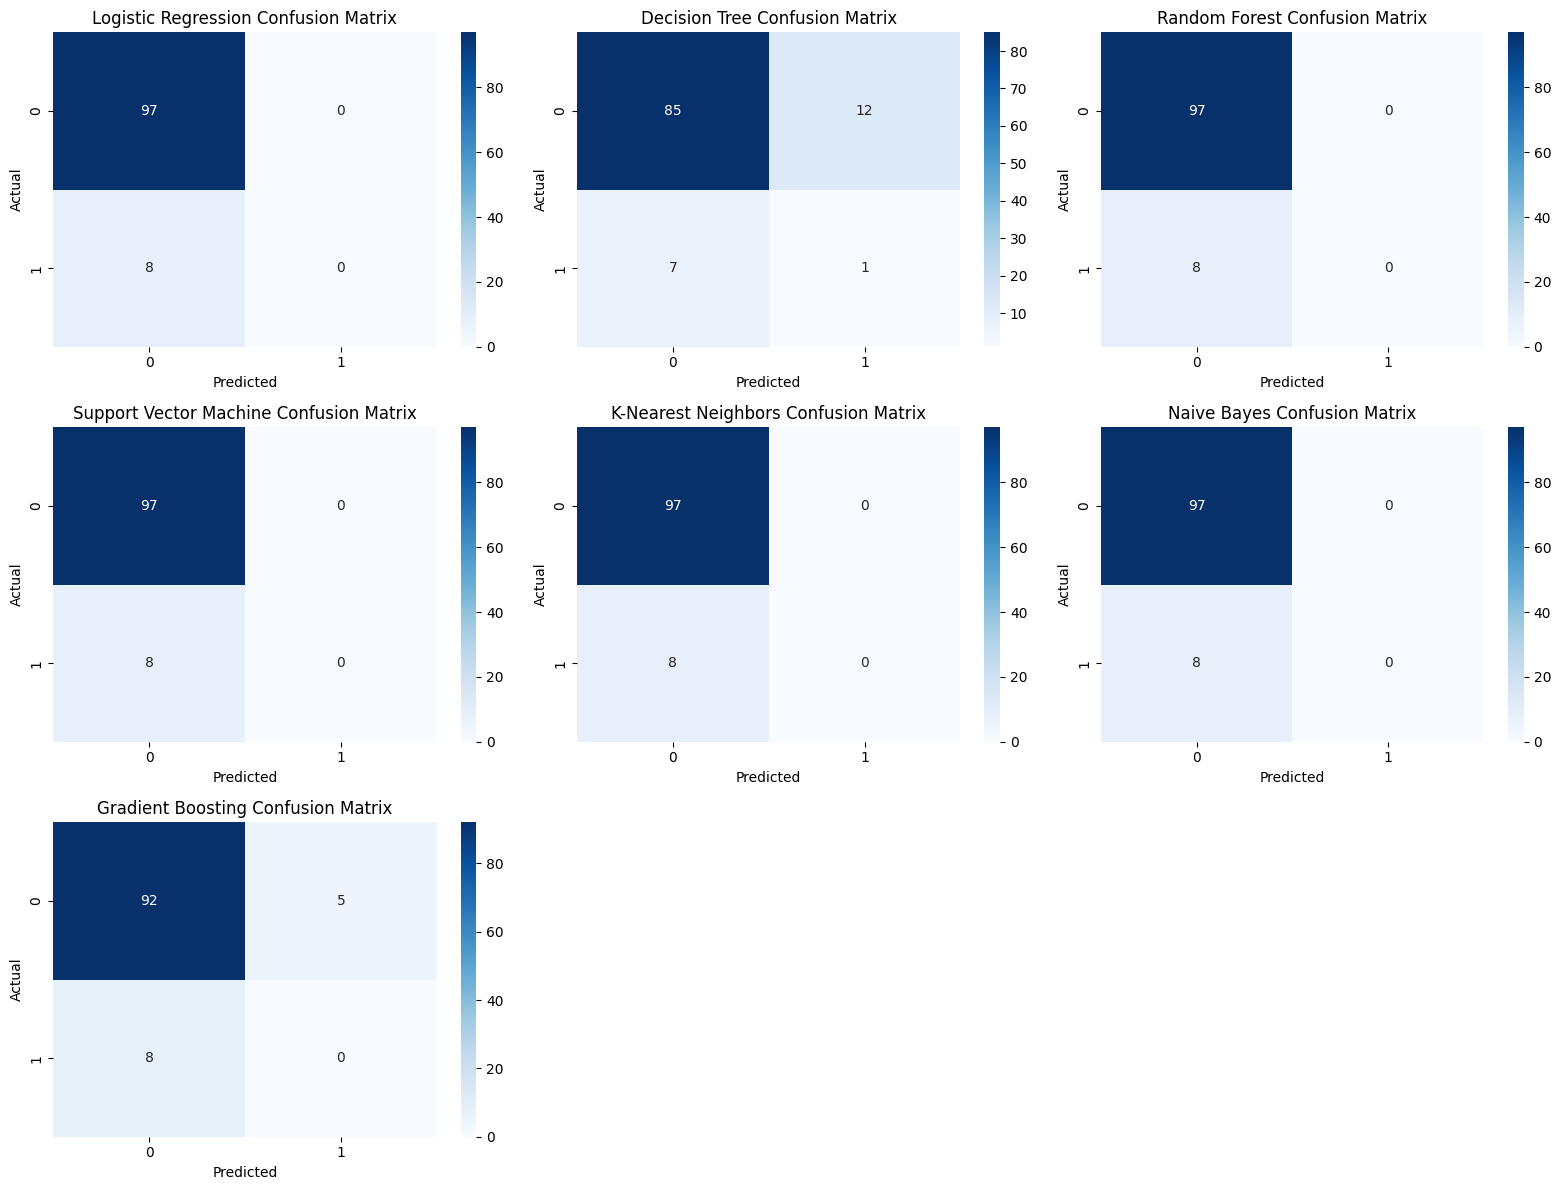

In [25]:
fig, axs = plt.subplots(3, 3, figsize=(16, 12))
axs = axs.ravel()

for i, (name, _, cm) in enumerate(results):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[i])
    axs[i].set_title(f"{name} Confusion Matrix")
    axs[i].set_xlabel("Predicted")
    axs[i].set_ylabel("Actual")

# Hide unused subplots
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()



## Thank you...pls upvote!!!!